In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

SCHED_DIR  = Path('outputs/scheduler_outputs')
CPS        = 100_000_000
DURATION_S = 10.0

HW_ORDER  = ['mono128', 'comp4x64', 'comp16x32', 'comp64x16']
HW_LABELS = {'mono128': '1×SA128', 'comp4x64': '4×SA64',
             'comp16x32': '16×SA32', 'comp64x16': '64×SA16'}

LP_KEYS   = ['fifo_greedy', 'lpt_greedy', 'deadline_greedy']
LP_LABELS = {'fifo_greedy': 'FIFO', 'lpt_greedy': 'LPT', 'deadline_greedy': 'Deadline'}
LP_COLORS = {'fifo_greedy': '#4878d0', 'lpt_greedy': '#6acc65', 'deadline_greedy': '#ee854a'}
ALLOC_VALUES = {'greedy', 'fair'}

THROUGHPUT_MODELS = ['emformer', 'mobilellm_125m']
LATENCY_MODELS    = ['hand_pose', 'eyecod', 'key_res15', 'tcn', 'd2go', 'deit_small']

# ── load summary CSVs ─────────────────────────────────────────────────────────
summaries = []
for p in sorted(SCHED_DIR.glob('xrbench_*_summary.csv')):
    tokens = p.stem.split('_')
    alloc  = tokens[-2] if tokens[-2] in ALLOC_VALUES else 'model'
    df = pd.read_csv(p)
    df['alloc'] = alloc
    summaries.append(df)

sched_all = pd.concat(summaries, ignore_index=True)
sched_all = sched_all[sched_all['scenario'] == 'xrbench_8model'].copy()
sched_all['lp_key'] = (
    sched_all['policy'].str.replace('deadline_task_aware', 'deadline', regex=False)
    + '_' + sched_all['alloc']
)
sched = sched_all[sched_all['lp_key'].isin(LP_KEYS)].copy()
util_pivot = sched.pivot_table(index='hardware', columns='lp_key',
                               values='pe_utilization', aggfunc='first').reindex(HW_ORDER)

# ── load trace CSVs ───────────────────────────────────────────────────────────
POL_ORDER = ['fifo', 'lpt', 'deadline_task_aware']
traces = []
for path in sorted(SCHED_DIR.glob('*8model*_trace.csv')):
    tokens = path.stem.split('_')
    alloc  = tokens[-2] if tokens[-2] in ALLOC_VALUES else 'model'
    hw     = next((h for h in HW_ORDER  if h in path.stem), None)
    pol    = next((p for p in POL_ORDER if p in path.stem), None)
    if hw is None or pol is None or alloc == 'model':
        continue
    lp_key = f"{pol.replace('deadline_task_aware','deadline')}_{alloc}"
    if lp_key not in LP_KEYS:
        continue
    df = pd.read_csv(path)
    df['hardware'] = hw
    df['lp_key']   = lp_key
    if 'mode' not in df.columns:
        df['mode'] = df['model'].map(
            lambda m: 'throughput' if m in THROUGHPUT_MODELS else 'latency')
    traces.append(df)

trace = pd.concat(traces, ignore_index=True)

# ── latency stats ─────────────────────────────────────────────────────────────
# deadline_miss=1 covers both evicted and tardy requests.
# Response time is computed only over on-time completions (deadline_miss=0).
lat_all  = trace[trace['mode'] == 'latency'].copy()
lat_hit  = lat_all[lat_all['deadline_miss'] == 0].copy()
lat_hit['response_ms'] = lat_hit['response_cycles'] / CPS * 1000

resp_stats = (lat_hit.groupby(['hardware', 'lp_key'])
              .agg(mean_resp_ms=('response_ms', 'mean'))
              .reset_index())
miss_stats = (lat_all.groupby(['hardware', 'lp_key'])
              .agg(miss_pct=('deadline_miss', lambda x: x.mean() * 100))
              .reset_index())
lat_stats = resp_stats.merge(miss_stats, on=['hardware', 'lp_key'])

lat_piv  = lat_stats.pivot(index='hardware', columns='lp_key', values='mean_resp_ms').reindex(HW_ORDER)
miss_piv = lat_stats.pivot(index='hardware', columns='lp_key', values='miss_pct').reindex(HW_ORDER)

# ── throughput (throughput-mode models, on-time only) ─────────────────────────
tp_trace  = trace[(trace['mode'] == 'throughput') & (trace['deadline_miss'] == 0)].copy()
tp_counts = (tp_trace.groupby(['hardware', 'lp_key', 'model'])
             .size().reset_index(name='completions'))
tp_counts['throughput_rps'] = tp_counts['completions'] / DURATION_S

print(f"Latency arrivals   : {len(lat_all):,}")
print(f"Latency on-time    : {len(lat_hit):,}")
print(f"Throughput completions: {len(tp_trace):,}")
print("\nMiss rate preview:")
print(miss_piv.round(1).to_string())

Latency arrivals   : 33,600
Latency on-time    : 30,060
Throughput completions: 3,259

Miss rate preview:
lp_key     deadline_greedy  fifo_greedy  lpt_greedy
hardware                                           
mono128               11.5         22.4        41.5
comp4x64               4.5          9.2        12.0
comp16x32              4.6          3.8         5.0
comp64x16              4.1          3.7         4.1


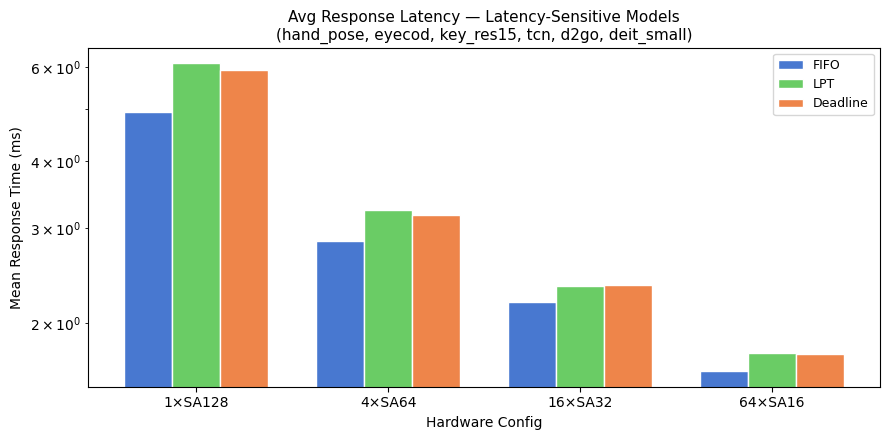

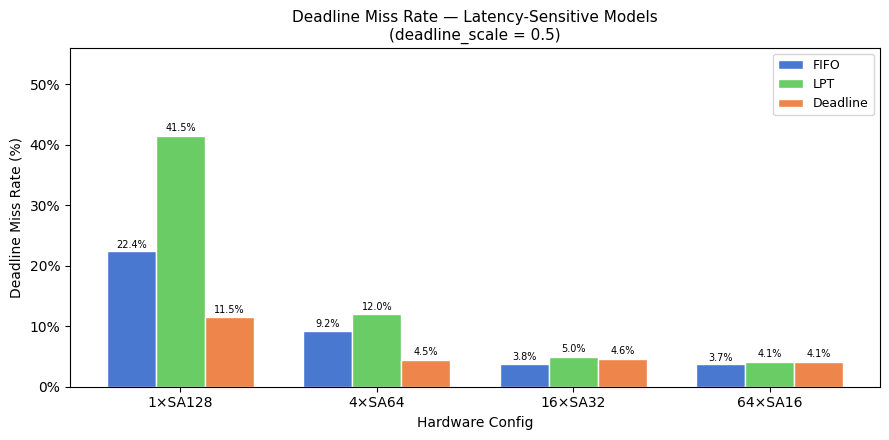

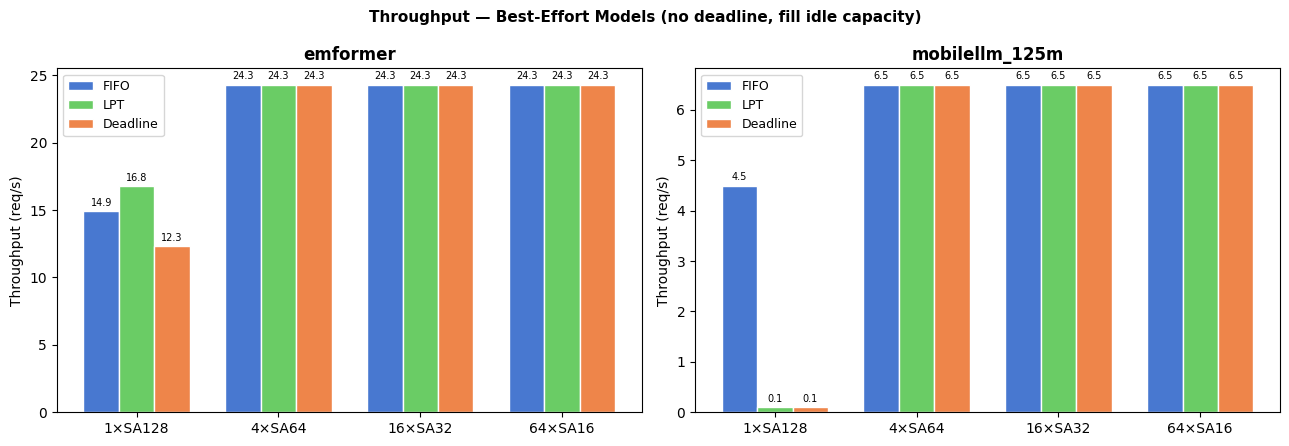

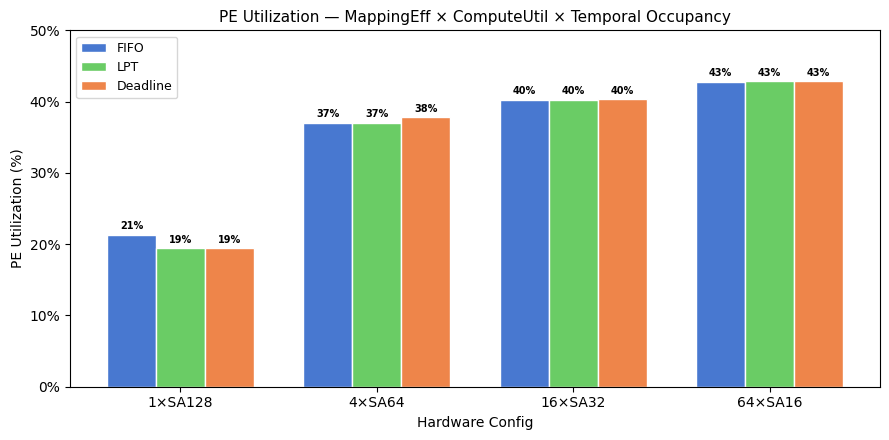

In [12]:
x   = np.arange(len(HW_ORDER))
w   = 0.25
xlabels = [HW_LABELS[h] for h in HW_ORDER]

def bar_group(ax, pivot, lp_keys, colors, labels, fmt=None):
    """Draw a 3-bar group per x position from a (hardware → lp_key) pivot."""
    for i, lp in enumerate(lp_keys):
        vals = pivot[lp].values.astype(float)
        bars = ax.bar(x + (i - 1) * w, vals, w,
                      label=labels[lp], color=colors[lp], edgecolor='white')
        if fmt:
            for bar, v in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        v + ax.get_ylim()[1] * 0.01,
                        fmt % v, ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels)
    ax.legend(fontsize=9)

# ─────────────────────────────────────────────────────────────────────────────
# Fig 1 — Average Response Latency (on-time completions only)
# ─────────────────────────────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(9, 4.5))
bar_group(ax1, lat_piv, LP_KEYS, LP_COLORS, LP_LABELS)
ax1.set_ylabel('Mean Response Time (ms)')
ax1.set_xlabel('Hardware Config')
ax1.set_title('Avg Response Latency — Latency-Sensitive Models\n'
              f'({", ".join(LATENCY_MODELS)})', fontsize=11)
ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.2f}'))
plt.tight_layout()
plt.savefig('outputs/latency.pdf', bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Fig 2 — Deadline Miss Rate (latency-mode models)
# ─────────────────────────────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(9, 4.5))
ylim_miss = max(10.0, float(miss_piv.max().max()) * 1.35)
bar_group(ax2, miss_piv, LP_KEYS, LP_COLORS, LP_LABELS, fmt='%.1f%%')
ax2.set_ylabel('Deadline Miss Rate (%)')
ax2.set_xlabel('Hardware Config')
ax2.set_title('Deadline Miss Rate — Latency-Sensitive Models\n'
              f'(deadline_scale = 0.5)', fontsize=11)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
ax2.set_ylim(0, ylim_miss)
plt.tight_layout()
plt.savefig('outputs/miss_rate.pdf', bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Fig 3 — Throughput (throughput-mode models)
# ─────────────────────────────────────────────────────────────────────────────
fig3, axes3 = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)

for ax, model in zip(axes3, THROUGHPUT_MODELS):
    sub = tp_counts[tp_counts['model'] == model]
    tp_piv = (sub.pivot(index='hardware', columns='lp_key', values='throughput_rps')
                 .reindex(index=HW_ORDER, columns=LP_KEYS)
                 .fillna(0))
    for i, lp in enumerate(LP_KEYS):
        vals = tp_piv[lp].values.astype(float)
        bars = ax.bar(x + (i - 1) * w, vals, w,
                      label=LP_LABELS[lp], color=LP_COLORS[lp], edgecolor='white')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    v + tp_piv.values.max() * 0.01,
                    f'{v:.1f}', ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels)
    ax.set_ylabel('Throughput (req/s)')
    ax.set_title(model, fontweight='bold')
    ax.legend(fontsize=9)

fig3.suptitle('Throughput — Best-Effort Models (no deadline, fill idle capacity)',
              fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/throughput.pdf', bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Fig 4 — PE Utilization
# ─────────────────────────────────────────────────────────────────────────────
util_pct = util_pivot * 100

fig4, ax4 = plt.subplots(figsize=(9, 4.5))
for i, lp in enumerate(LP_KEYS):
    vals = util_pct[lp].values.astype(float)
    bars = ax4.bar(x + (i - 1) * w, vals, w,
                   label=LP_LABELS[lp], color=LP_COLORS[lp], edgecolor='white')
    for bar, v in zip(bars, vals):
        ax4.text(bar.get_x() + bar.get_width() / 2,
                 v + 0.5, f'{v:.0f}%',
                 ha='center', va='bottom', fontsize=7, fontweight='bold')

ax4.set_xticks(x)
ax4.set_xticklabels(xlabels)
ax4.set_ylabel('PE Utilization (%)')
ax4.set_xlabel('Hardware Config')
ax4.set_title('PE Utilization — MappingEff × ComputeUtil × Temporal Occupancy', fontsize=11)
ax4.yaxis.set_major_formatter(mticker.PercentFormatter())
ax4.set_ylim(0, 50)
ax4.legend(fontsize=9)
plt.tight_layout()
plt.savefig('outputs/utilization.pdf', bbox_inches='tight')
plt.show()